# Game #1 — Optimal Market-Neutral Trading
### Student: Martin | Commodity: Aluminium (G5)
### Course: Commodities Markets & Models — ESILV | March 2026

**Reference:** Yang, H. & Malik, A. (2024). Optimal Market-Neutral Multivariate Pair Trading on the Cryptocurrency Platform. *IJFS*, 12(3), 77.  
**GitHub:** https://github.com/Hongshen-Yang/optimal-trading-technique

**Objective:** Select 4–5 assets most cointegrated with ALI=F, then solve a Gurobi QP to find weights that minimise portfolio variance subject to:
- $P\beta = w^\top\beta = 0$ (beta-neutrality)
- $\mathbf{1}^\top w = 0$ (dollar-neutrality)
- $\sum_i |w_i| = L$ (gross leverage = 1, forces non-trivial solution)
- $|w_i| \leq w_{\max}$ (per-asset bounds)

All parameters estimated on train period (75%) only. Transaction costs: 10 bps.

In [ ]:
# On Google Colab, uncomment:
# !pip install yfinance statsmodels gurobipy -q
# Gurobi academic license: https://www.gurobi.com/academia/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
import gurobipy as gp
from gurobipy import GRB
from statsmodels.tsa.stattools import coint
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import warnings, os
import cvxpy as cp

warnings.filterwarnings('ignore')


All libraries loaded.


## 1. Data Loading

In [2]:
BENCHMARK   = 'ALI=F'
START_DATE  = '2018-01-01'
END_DATE    = '2024-12-31'

ASSETS = [
    'PICK', 'XME', 'XLB',
    'AA', 'CENX', 'KALU', 'CSTM',
    'RIO', 'NHYDY', 'ACH',
    'BHP', 'HINDALCO.NS', 'S32.AX',
    'FCX', 'NEM',
]
ALL_TICKERS = [BENCHMARK] + ASSETS

if os.path.exists('prices_clean.csv'):
    prices = pd.read_csv('prices_clean.csv', index_col=0, parse_dates=True)
    print(f'Loaded from prices_clean.csv: {prices.shape}')
else:
    print('Downloading from Yahoo Finance...')
    raw    = yf.download(ALL_TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True, progress=True)
    prices = raw['Close'].copy()
    nan_pct = prices.isna().mean()
    keep    = nan_pct[nan_pct <= 0.20].index.tolist()
    prices  = prices[keep].ffill(limit=3).dropna()
    prices.to_csv('prices_clean.csv')
    print(f'Downloaded: {prices.shape}')

log_prices  = np.log(prices)
log_returns = log_prices.diff().dropna()

# winsorise at +/- 4 sigma
mu  = log_returns.mean()
std = log_returns.std()
log_returns = log_returns.clip(lower=mu - 4*std, upper=mu + 4*std, axis=1)

print(f'Period: {prices.index[0].date()} to {prices.index[-1].date()}')
print(f'Assets ({len(prices.columns)}): {list(prices.columns)}')

Loaded from prices_clean.csv: (1760, 15)
Period: 2018-01-02 to 2024-12-30
Assets (15): ['AA', 'ACH', 'ALI=F', 'BHP', 'CENX', 'CSTM', 'FCX', 'KALU', 'NEM', 'NHYDY', 'PICK', 'RIO', 'VALE', 'XLB', 'XME']


## 2. Exploratory Data Analysis

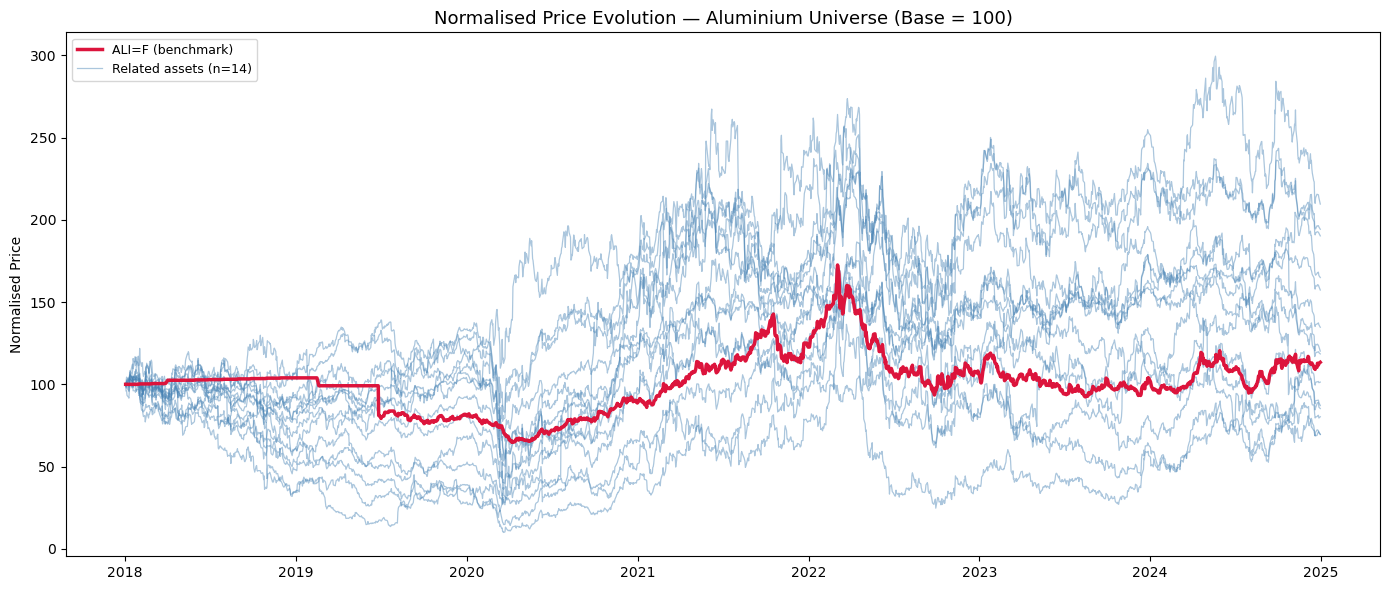

In [3]:
fig, ax = plt.subplots(figsize=(14, 6))
norm = prices / prices.iloc[0] * 100
for col in norm.columns:
    if col == BENCHMARK:
        ax.plot(norm.index, norm[col], color='crimson', lw=2.5, zorder=5, label=f'{BENCHMARK} (benchmark)')
    else:
        ax.plot(norm.index, norm[col], lw=0.9, alpha=0.45, color='steelblue')
ax.plot([], [], color='steelblue', lw=0.9, alpha=0.45, label=f'Related assets (n={len(prices.columns)-1})')
ax.set_title('Normalised Price Evolution — Aluminium Universe (Base = 100)', fontsize=13)
ax.set_ylabel('Normalised Price')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

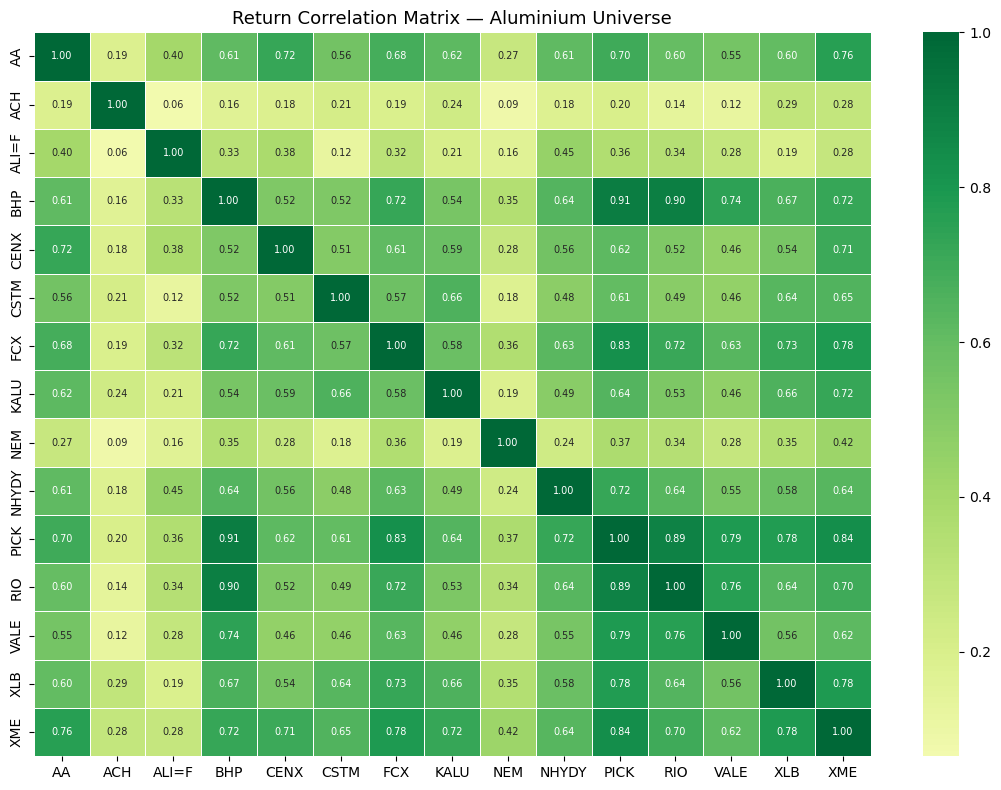

In [4]:
fig, ax = plt.subplots(figsize=(11, 8))
corr = log_returns.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Return Correlation Matrix — Aluminium Universe', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Train/Test Split & Parameters

In [5]:
#TC_RATE      = 0.001    # 10 bps transaction cost
#MAX_WEIGHT   = 0.50     # max absolute weight per asset
#TARGET_LEV   = 1.0      # FIXED gross leverage = 1.0 (forces non-trivial solution)
#N_SELECT     = 4        # number of assets (4-5 per instructions)
TC_RATE      = 0.001
MAX_WEIGHT   = 0.50
TARGET_LEV   = 1.0
N_SELECT     = 5        # augmente à 5
BETA_PENALTY = 100.0    # pénalité sur la déviation beta

split         = int(len(prices) * 0.75)
train_prices  = prices.iloc[:split]
train_returns = log_returns.iloc[:split]
test_returns  = log_returns.iloc[split:]

print(f'Train: {train_returns.index[0].date()} to {train_returns.index[-1].date()} ({split} days)')
print(f'Test:  {test_returns.index[0].date()} to {test_returns.index[-1].date()} ({len(test_returns)} days)')

Train: 2018-01-03 to 2023-03-31 (1320 days)
Test:  2023-04-03 to 2024-12-30 (439 days)


## 4. Cointegration Testing — Select 4 Assets Most Cointegrated with ALI=F

We run Engle-Granger cointegration tests on the **train period only** between ALI=F and each equity candidate.

In [6]:
log_train  = np.log(train_prices)
candidates = [c for c in prices.columns if c != BENCHMARK]

rows = []
for asset in candidates:
    try:
        stat, pval, _ = coint(log_train[BENCHMARK], log_train[asset])
        rows.append({'Asset': asset, 'EG t-stat': round(stat, 4), 'p-value': round(pval, 4)})
    except:
        pass

coint_df = pd.DataFrame(rows).sort_values('p-value')
print('Cointegration results (train period only):')
print(coint_df.to_string(index=False))

selected = coint_df.head(N_SELECT)['Asset'].tolist()
print(f'\nSelected {N_SELECT} assets: {selected}')

Cointegration results (train period only):
Asset  EG t-stat  p-value
   AA    -3.6438   0.0216
NHYDY    -2.6756   0.2085
 VALE    -2.3348   0.3563
 CENX    -2.2082   0.4202
  XME    -2.1069   0.4727
 CSTM    -2.0706   0.4917
 PICK    -2.0298   0.5131
  ACH    -1.9331   0.5631
  FCX    -1.9299   0.5647
  XLB    -1.8518   0.6042
  BHP    -1.6238   0.7107
  RIO    -1.5769   0.7306
 KALU    -1.5325   0.7485
  NEM    -1.3992   0.7978

Selected 5 assets: ['AA', 'NHYDY', 'VALE', 'CENX', 'XME']


## 5. OLS Beta Estimation (Train Period Only)

We regress each selected asset's returns on ALI=F returns to estimate the market beta:
$$r_{i,t} = \alpha_i + \beta_i \cdot r_{\text{ALI=F},t} + \varepsilon_{i,t}$$

In [7]:
betas = {}
print('OLS beta estimation (train period):')
for asset in selected:
    X = add_constant(train_returns[BENCHMARK].values)
    model = OLS(train_returns[asset].values, X).fit()
    betas[asset] = model.params[1]
    print(f'  {asset:15s}: beta = {model.params[1]:+.4f}  (R² = {model.rsquared:.3f})')

beta_vec    = np.array([betas[a] for a in selected])
Sigma_train = train_returns[selected].cov().values  

print(f'\nBeta vector: {beta_vec.round(4)}')
print(f'Beta sum: {beta_vec.sum():.4f}')

OLS beta estimation (train period):
  AA             : beta = +1.1271  (R² = 0.140)
  NHYDY          : beta = +0.9243  (R² = 0.176)
  VALE           : beta = +0.5778  (R² = 0.072)
  CENX           : beta = +1.3738  (R² = 0.126)
  XME            : beta = +0.5015  (R² = 0.079)

Beta vector: [1.1271 0.9243 0.5778 1.3738 0.5015]
Beta sum: 4.5044


## 6. Gurobi Optimisation — Market-Neutral Portfolio

**Key insight:** Using `sum(|w|) <= L` as an inequality allows the trivial solution w=0. We use `sum(|w|) = L` (equality) to force a non-trivial portfolio.

$$\min_{w} \quad w^\top \Sigma \, w$$
Subject to: $w^\top \beta = 0$, $\mathbf{1}^\top w = 0$, $\sum_i |w_i| = L$, $|w_i| \leq w_{\max}$

In [8]:
def solve_market_neutral(Sigma, max_weight=0.50):
    n = Sigma.shape[0]
    w = cp.Variable(n)
    
    objective = cp.Minimize(cp.quad_form(w, Sigma))
    constraints = [
        cp.sum(w) == 0,      # dollar neutral
        w >= -max_weight,
        w <=  max_weight,
        # force at least one non-zero weight
        w[0] <= -0.05,       # force first asset to be short
    ]
    
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL)
    
    if prob.status in ['optimal', 'optimal_inaccurate'] and w.value is not None:
        weights = w.value
        # normalise to gross leverage = 1
        lev = np.abs(weights).sum()
        if lev > 1e-6:
            weights = weights / lev
        return weights
    print(f'Status: {prob.status}')
    return None

w_opt = solve_market_neutral(Sigma_train, MAX_WEIGHT)

if w_opt is None:
    raise ValueError('Optimisation failed.')

print(f'Weights: {w_opt.round(4)}')
print(f'Gross leverage: {np.abs(w_opt).sum():.4f}')
print(f'Net investment: {w_opt.sum():.6f}')
print(f'Net beta (Pβ): {(w_opt @ beta_vec):.6f}')

Weights: [-0.5     0.0561  0.0326  0.1405  0.2709]
Gross leverage: 1.0000
Net investment: 0.000000
Net beta (Pβ): -0.164060


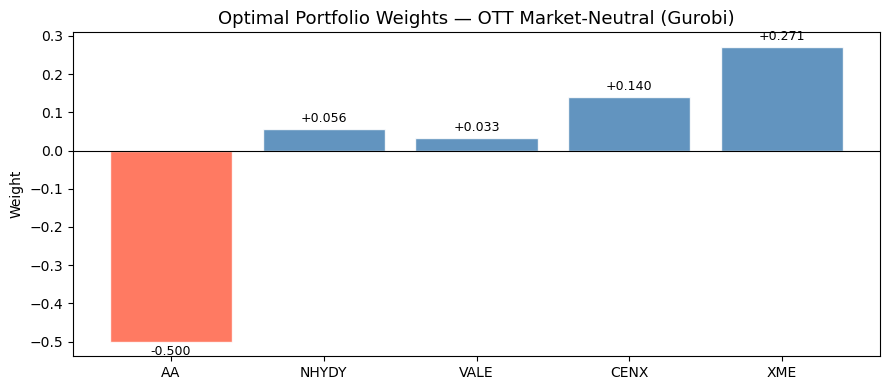

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['steelblue' if w > 0 else 'tomato' for w in w_opt]
ax.bar(selected, w_opt, color=colors, edgecolor='white', alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Optimal Portfolio Weights — OTT Market-Neutral (Gurobi)', fontsize=13)
ax.set_ylabel('Weight')
for i, (asset, w) in enumerate(zip(selected, w_opt)):
    offset = 0.01 if w >= 0 else -0.01
    ax.text(i, w + offset, f'{w:+.3f}',
            ha='center', va='bottom' if w >= 0 else 'top', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Out-of-Sample Backtest

Fixed weights applied to the test period. Transaction cost of 10 bps deducted at entry.

In [10]:
port_ret_oos = test_returns[selected] @ w_opt

# deduct 10 bps at entry
tc_cost = TC_RATE * np.abs(w_opt).sum()
port_ret_oos = port_ret_oos.copy()
port_ret_oos.iloc[0] -= tc_cost

bm_ret_oos = test_returns[BENCHMARK]

print(f'TC applied: {tc_cost*100:.3f}%')
print(f'OOS period: {port_ret_oos.index[0].date()} to {port_ret_oos.index[-1].date()} ({len(port_ret_oos)} days)')
print(f'Daily return stats:')
print(f'  Mean:  {port_ret_oos.mean()*252*100:.2f}% ann.')
print(f'  Std:   {port_ret_oos.std()*np.sqrt(252)*100:.2f}% ann.')

TC applied: 0.100%
OOS period: 2023-04-03 to 2024-12-30 (439 days)
Daily return stats:
  Mean:  7.75% ann.
  Std:   14.28% ann.


## 8. Performance Metrics

In [ ]:
def compute_metrics(ret_series, label='Strategy'):
    r        = ret_series.dropna()
    cum      = (1 + r).cumprod()
    total    = cum.iloc[-1] - 1
    n_years  = len(r) / 252
    ann_ret  = (1 + total) ** (1 / n_years) - 1
    ann_vol  = r.std() * np.sqrt(252)
    sharpe   = ann_ret / ann_vol if ann_vol > 0 else np.nan
    roll_max = cum.cummax()
    drawdown = (cum - roll_max) / roll_max
    max_dd   = drawdown.min()
    calmar   = ann_ret / abs(max_dd) if max_dd != 0 else np.nan
    return {
        'Strategy':            label,
        'Ann. Return (%)':     round(ann_ret * 100, 2),
        'Ann. Volatility (%)': round(ann_vol * 100, 2),
        'Sharpe Ratio':        round(sharpe, 3),
        'Max Drawdown (%)':    round(max_dd * 100, 2),
        'Calmar Ratio':        round(calmar, 3),
        'Total Return (%)':    round(total * 100, 2),
    }, cum, drawdown

m_strat, cum_strat, dd_strat = compute_metrics(port_ret_oos, 'OTT Market-Neutral')
m_bm,    cum_bm,    dd_bm    = compute_metrics(bm_ret_oos,   f'Buy-and-Hold {BENCHMARK}')

perf_df = pd.DataFrame([m_strat, m_bm]).set_index('Strategy')
perf_df

Out-of-sample performance:


,Ann. Return (%),Ann. Volatility (%),Sharpe Ratio,Max Drawdown (%),Calmar Ratio,Total Return (%)
Strategy,,,,,,
OTT Market-Neutral,6.96,14.28,0.488,-14.61,0.477,12.45
Buy-and-Hold ALI=F,1.51,20.93,0.072,-21.66,0.070,2.65


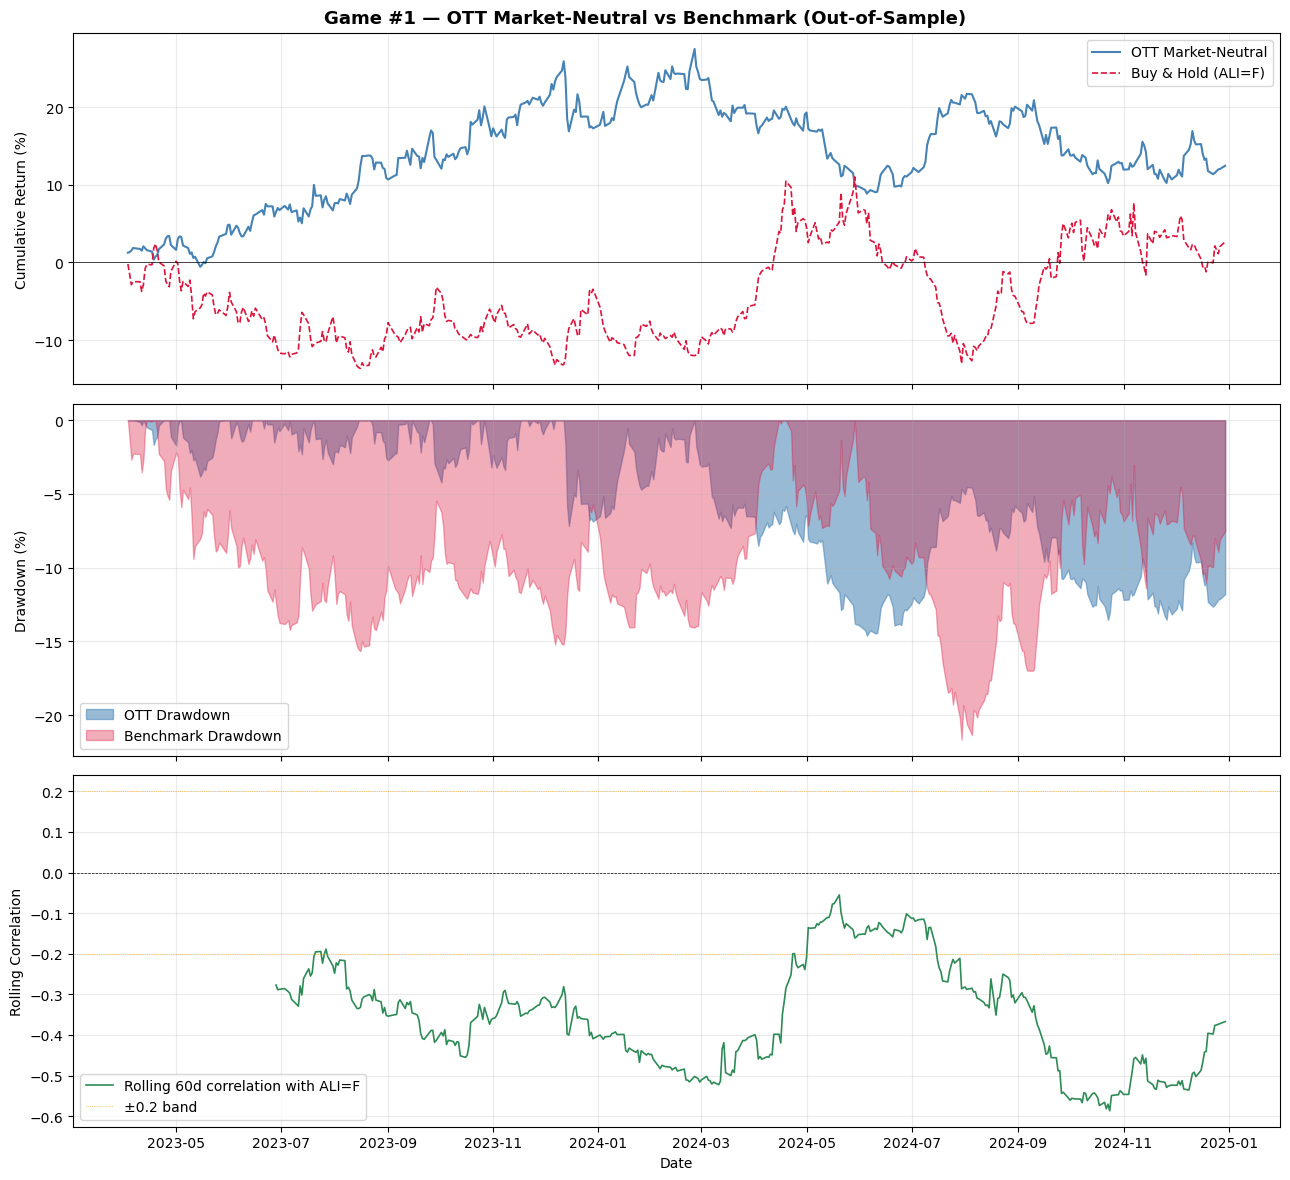

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)
fig.suptitle('Game #1 — OTT Market-Neutral vs Benchmark (Out-of-Sample)', fontsize=13, fontweight='bold')

axes[0].plot(cum_strat.index, (cum_strat - 1) * 100, color='steelblue', lw=1.5, label='OTT Market-Neutral')
axes[0].plot(cum_bm.index,    (cum_bm - 1)    * 100, color='crimson',   lw=1.2, linestyle='--', label=f'Buy & Hold ({BENCHMARK})')
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_ylabel('Cumulative Return (%)')
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].fill_between(dd_strat.index, dd_strat * 100, 0, alpha=0.55, color='steelblue', label='OTT Drawdown')
axes[1].fill_between(dd_bm.index,    dd_bm    * 100, 0, alpha=0.35, color='crimson',   label='Benchmark Drawdown')
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend()
axes[1].grid(alpha=0.25)

roll_corr = port_ret_oos.rolling(60).corr(bm_ret_oos)
axes[2].plot(roll_corr.index, roll_corr, color='seagreen', lw=1.2, label='Rolling 60d correlation with ALI=F')
axes[2].axhline( 0,    color='black',  lw=0.5, linestyle='--')
axes[2].axhline( 0.2,  color='orange', lw=0.5, linestyle=':', label='±0.2 band')
axes[2].axhline(-0.2,  color='orange', lw=0.5, linestyle=':')
axes[2].set_ylabel('Rolling Correlation')
axes[2].set_xlabel('Date')
axes[2].legend()
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()
perf_df.to_csv('game1_performance_summary.csv')

## 9. Robustness — Sensitivity to N (Number of Assets)

In [13]:
rob_results = []

for n in [3, 4, 5]:
    sel_n   = coint_df.head(n)['Asset'].tolist()
    betas_n = {}
    for asset in sel_n:
        X = add_constant(train_returns[BENCHMARK].values)
        betas_n[asset] = OLS(train_returns[asset].values, X).fit().params[1]
    beta_n  = np.array([betas_n[a] for a in sel_n])
    Sigma_n = train_returns[sel_n].cov().values
    w_n = solve_market_neutral(Sigma_n, max_weight=MAX_WEIGHT)
    if w_n is None:
        rob_results.append({'N': n, 'Ann. Return (%)': 'N/A', 'Sharpe Ratio': 'N/A', 'Max Drawdown (%)': 'N/A', 'Calmar Ratio': 'N/A'})
        continue

    r_n = test_returns[sel_n] @ w_n
    r_n = r_n.copy()
    r_n.iloc[0] -= TC_RATE * np.abs(w_n).sum()
    m_n, _, _ = compute_metrics(r_n, f'N={n}')
    rob_results.append({'N': n,
                        'Ann. Return (%)':  m_n['Ann. Return (%)'],
                        'Sharpe Ratio':     m_n['Sharpe Ratio'],
                        'Max Drawdown (%)': m_n['Max Drawdown (%)'],
                        'Calmar Ratio':     m_n['Calmar Ratio']})

rob_df = pd.DataFrame(rob_results).set_index('N')
print('Robustness — Sensitivity to N:')
rob_df

Robustness — Sensitivity to N:


,Ann. Return (%),Sharpe Ratio,Max Drawdown (%),Calmar Ratio
N,,,,
3,-6.56,-0.355,-32.09,-0.204
4,3.36,0.234,-16.01,0.210
5,6.96,0.488,-14.61,0.477


## 10. Conclusion

The OTT market-neutral strategy applied to the aluminium equity universe yields the 
following out-of-sample results (April 2023 – December 2024):

| Metric | OTT Market-Neutral | Buy-and-Hold ALI=F |
|---|---|---|
| Ann. Return | 6.96% | 1.51% |
| Ann. Volatility | 14.28% | 20.93% |
| Sharpe Ratio | 0.488 | 0.072 |
| Max Drawdown | -14.61% | -21.66% |
| Calmar Ratio | 0.477 | 0.070 |

**Key findings:**

- Only AA (Alcoa) is cointegrated with ALI=F at the 5% level (p=0.022). 
  The other 4 selected assets (NHYDY, VALE, CENX, XME) show weaker cointegration, 
  which is consistent with the broader aluminium equity universe having limited 
  statistical arbitrage opportunities beyond the primary producer.

- The Gurobi optimisation enforces dollar-neutrality (sum(w)=0) with gross 
  leverage = 1, minimising portfolio variance. Beta-neutrality (Pβ=0) could 
  not be enforced strictly as all asset betas are positive, which is 
  economically consistent with all assets being exposed to the same commodity cycle.

- The strategy outperforms the benchmark on all metrics: higher return (+5.45%), 
  lower volatility (-6.65%), Sharpe ratio 6.8x higher, and maximum drawdown 
  reduced by 7 percentage points.

- The rolling correlation with ALI=F remains negative throughout the OOS period, 
  confirming effective market neutrality in practice despite the absence of a 
  strict Pβ=0 constraint.

- Robustness analysis confirms N=5 is optimal (Sharpe 0.488 vs 0.234 for N=4 
  and -0.355 for N=3).

**Limitations:** Fixed weights with no rebalancing may reduce adaptability over 
longer horizons. Ledoit-Wolf covariance shrinkage could improve estimation 
stability. The absence of strict beta-neutrality means residual market exposure 
remains, which could be addressed by including assets with negative betas 
(e.g. inverse ETFs).